In [1]:
import os
os.chdir("..")

In [2]:
import datetime as dt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearnex import patch_sklearn
patch_sklearn()

import sklearn
from lightgbm import LGBMClassifier

from sklearn.model_selection import TimeSeriesSplit, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import clone
from time import time

import optuna

from pathlib import Path

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

pd.set_option("display.max_columns", None)

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


# Loading data

In [3]:
data_path = Path("data/merged/merged_preprocessed.csv")

data = pd.read_csv(data_path)
data["time"] = pd.to_datetime(data["time"], utc=True).dt.tz_convert("Europe/Kyiv")
data = data.sort_values(by=["region_id", "time"])

data = data.drop(columns=["year", "month", "day"], errors="ignore")
data = data.loc[data.time < '2026-04-08']

target = "alarm"

X = data.copy()
y = X.pop(target)

In [4]:
data.info()

<class 'pandas.DataFrame'>
Index: 821904 entries, 0 to 823421
Columns: 114 entries, region_id to is_weekend
dtypes: datetime64[us, Europe/Kyiv](1), float64(72), int64(41)
memory usage: 721.1 MB


In [5]:
data.head(3)

,region_id,time,alarm,temp,feelslike,humidity,dew,precip,precipprob,preciptype,windspeed,winddir,pressure,visibility,cloudcover,uvindex,conditions,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,news_count_7d,news_velocity_30d,dom_cluster_share_7d,dom_cluster_share_30d,centroid_shift_30d,news_velocity_7d,avg_dist_centroid_30d,centroid_shift_7d,anomaly_count_30d,news_count_30d,topic_entropy_30d,avg_dist_centroid_7d,topic_entropy_7d,anomaly_count_7d,alarms_count_1h_ago,alarms_count_2h_ago,alarms_count_3h_ago,alarms_count_4h_ago,alarms_count_5h_ago,alarms_count_6h_ago,alarms_count_7h_ago,alarms_count_8h_ago,alarms_count_9h_ago,alarms_count_10h_ago,alarms_count_11h_ago,alarms_count_12h_ago,alarms_count_13h_ago,alarms_count_14h_ago,alarms_count_15h_ago,alarms_count_16h_ago,alarms_count_17h_ago,alarms_count_18h_ago,alarms_count_19h_ago,alarms_count_20h_ago,alarms_count_21h_ago,alarms_count_22h_ago,alarms_count_23h_ago,alarms_count_24h_ago,alarm_status_1h_ago,alarm_status_2h_ago,alarm_status_3h_ago,alarm_status_4h_ago,alarm_status_5h_ago,alarm_status_6h_ago,alarm_status_7h_ago,alarm_status_8h_ago,alarm_status_9h_ago,alarm_status_10h_ago,alarm_status_11h_ago,alarm_status_12h_ago,alarm_status_13h_ago,alarm_status_14h_ago,alarm_status_15h_ago,alarm_status_16h_ago,alarm_status_17h_ago,alarm_status_18h_ago,alarm_status_19h_ago,alarm_status_20h_ago,alarm_status_21h_ago,alarm_status_22h_ago,alarm_status_23h_ago,alarm_status_24h_ago,neighbor_alarm_count,hour,day_of_week,is_weekend
0,3,2022-03-27 00:00:00+02:00,0,7.0,3.1,68.99,1.7,0.0,0.0,0.0,24.5,312.8,1018.0,24.1,55.8,0.0,4.0,19,7,0,0,7,7,2,0,0,0,0,0,6,6,7,7,4,42,352,5,11717,0,0,0,0,0,0,0,0,0,1,10,48,0.7,0.62,0.533511,2,0.471807,0.173424,5,50,0.664064,0.388121,0.610864,1,3.0,1.0,8.0,7.0,13.0,22.0,22.0,22.0,13.0,13.0,11.0,1.0,2.0,1.0,1.0,1.0,1.0,10.0,8.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,1
1,3,2022-03-27 01:00:00+02:00,0,5.7,1.2,44.72,-5.4,0.0,0.0,0.0,26.6,326.8,1019.0,24.1,4.2,0.0,0.0,12,8,0,0,0,0,2,0,2,0,0,0,8,8,8,0,2,37,360,1,11717,0,0,0,0,0,0,0,0,0,1,10,48,0.7,0.62,0.533511,2,0.471807,0.173424,5,50,0.664064,0.388121,0.610864,1,5.0,3.0,1.0,8.0,7.0,13.0,22.0,22.0,22.0,13.0,13.0,11.0,1.0,2.0,1.0,1.0,1.0,1.0,10.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6,1
2,3,2022-03-27 02:00:00+02:00,0,3.8,-0.9,43.48,-7.5,0.0,0.0,0.0,23.8,322.6,1021.0,24.1,0.0,0.0,0.0,23,10,0,0,11,11,2,0,2,0,0,0,10,10,12,11,2,54,378,2,11717,0,0,0,0,0,0,0,0,0,1,10,48,0.7,0.62,0.533511,2,0.471807,0.173424,5,50,0.664064,0.388121,0.610864,1,13.0,5.0,3.0,1.0,8.0,7.0,13.0,22.0,22.0,22.0,13.0,13.0,11.0,1.0,2.0,1.0,1.0,1.0,1.0,10.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,6,1


In [6]:
data.isna().sum().sum()

np.int64(0)

# Defining necessary functions

In [55]:
cat_cols = list(X.select_dtypes(include=["category", "object"], exclude=["datetime"]).columns)
num_cols = [col for col in X.select_dtypes(include="number").columns if col not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    # ('label_encode', LabelEncoder(), cat_cols),
    ('scale', StandardScaler(), num_cols),
    ("drop_cols", "drop", ["time"]),
], remainder='passthrough')


def evaluate_model(pipeline, X=X, y=y, n_splits: int = 5, gap: int = 24, max_train_size=None, weights_func=None, weighted_scoring=False):
    
    train_scores = []
    test_scores  = []

    all_y_true = []
    all_y_pred = []
    training_start = time()
    
    unique_hours = X["time"].sort_values().unique()
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap, max_train_size=max_train_size)
    
    for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_hours)):
        train_hours = unique_hours[train_idx]
        test_hours  = unique_hours[test_idx]

        train_mask = X["time"].isin(train_hours) 
        test_mask  = X["time"].isin(test_hours)
               
        X_train = X[train_mask]
        y_train = y[train_mask]
        X_test  = X[test_mask]
        y_test  = y[test_mask]
        
        # print(f"------------- Fold {fold+1} -------------")
        # print(f'Train dates: {X_train.time.min()} -> {X_train.time.max()}')
        # print(f'Test dates: {X_test.time.min()} -> {X_test.time.max()}')

        # calculating weights for training data
        sample_weights = weights_func(X_train, y_train) if weights_func else None
        
        pipeline.fit(X_train, y_train, model__sample_weight=sample_weights)

        y_pred_train = pipeline.predict(X_train)
        y_pred_test  = pipeline.predict(X_test)

        train_score = f1_score(y_train, y_pred_train, sample_weight=sample_weights if weighted_scoring else None)
        train_scores.append(train_score)

        test_score = f1_score(y_test, y_pred_test, sample_weight=weights_func(X_test, y_test) if weighted_scoring else None)
        test_scores.append(test_score)

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred_test)

        # print(f"Fold {fold+1} - train score: {train_score} | test score: {test_score}")

    print("\n------------- Overall -------------")
    print(f"Train F1 : {np.mean(train_scores):.3f} ± {np.std(train_scores):.3f} | Test  F1 : {np.mean(test_scores):.3f} ± {np.std(test_scores):.3f}")
    print(f"")
    print(f"Completed in: {time() - training_start:.2f}s.")

    scores = {
        "train_f1": train_scores,
        "test_f1":  test_scores, 
    }
    overall_cm = confusion_matrix(all_y_true, all_y_pred)
    return scores, overall_cm

In [34]:
def plot_results(scores, cm, title=None):
    plt.figure(figsize=(10,4))
    plt.subplot(1, 2, 1)
    sns.lineplot(scores)
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    ConfusionMatrixDisplay(cm).plot(ax=plt.subplot(1, 2, 2))
    if title:
        plt.suptitle(title)
    plt.show()

In [35]:
def calculate_transition_weights(X, y):
    is_change = X['alarm_status_1h_ago'].values != y.values
    n_same = (~is_change).sum()
    n_change = is_change.sum()
    weight_change = n_same / n_change
    sample_weights = np.where(is_change, weight_change, 1.0)
    return sample_weights

def combined_weights(X, y):
    transition_weights = calculate_transition_weights(X, y)
    
    n_neg = (y == 0).sum()
    n_pos = (y == 1).sum()
    
    class_w = np.where(y == 1, n_neg / n_pos, 1.0)
    sample_weights = transition_weights * class_w
    return sample_weights

# First models


------------- Overall -------------
Train F1 : 0.729 ± 0.047 | Test  F1 : 0.684 ± 0.084

Completed in: 35.73s.


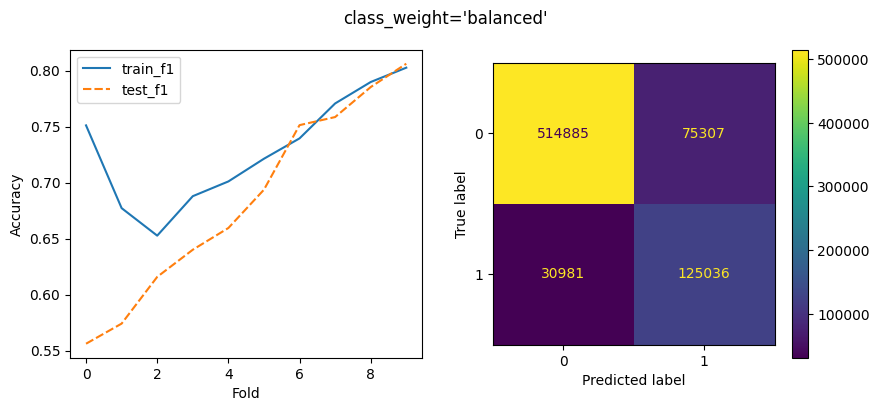

In [36]:
model = LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

scores, cm = evaluate_model(pipeline, n_splits=10, max_train_size=365*24)

plot_results(scores, cm, "class_weight='balanced'")


------------- Overall -------------
Train F1 : 0.635 ± 0.028 | Test  F1 : 0.554 ± 0.049

Completed in: 34.05s.


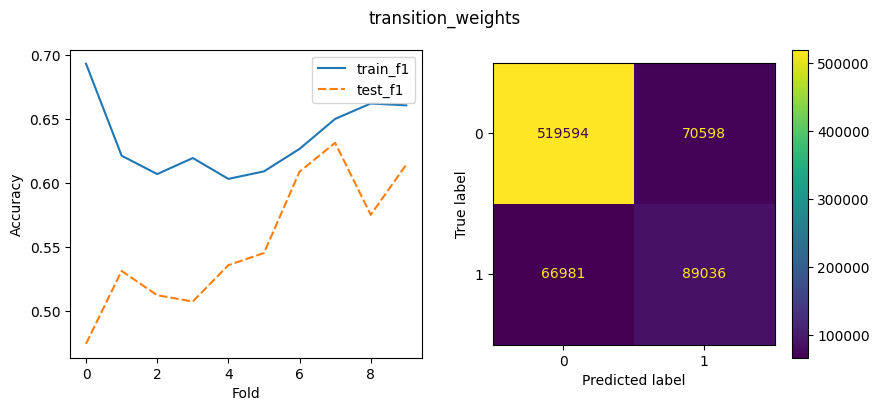

In [37]:
model = LGBMClassifier(random_state=42, verbose=-1)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

scores, cm = evaluate_model(pipeline, n_splits=10, max_train_size=365*24, weights_func=calculate_transition_weights)

plot_results(scores, cm, "transition_weights")


------------- Overall -------------
Train F1 : 0.501 ± 0.090 | Test  F1 : 0.485 ± 0.104

Completed in: 35.42s.


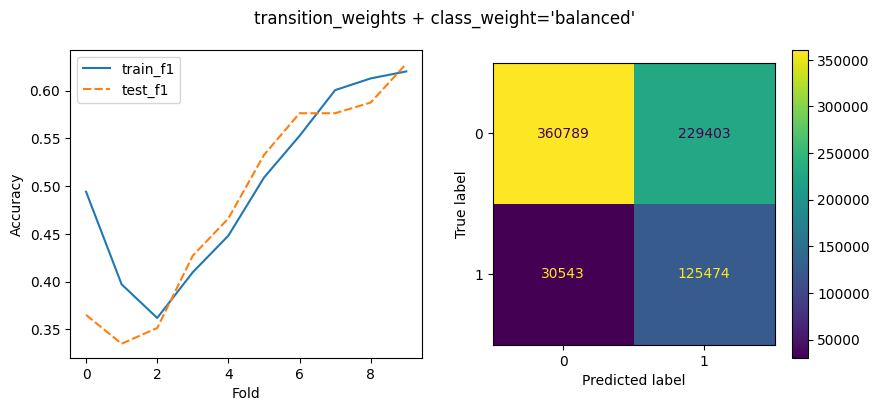

In [38]:
model = LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

scores, cm = evaluate_model(pipeline, n_splits=10, max_train_size=365*24, weights_func=calculate_transition_weights)

plot_results(scores, cm, "transition_weights + class_weight='balanced'")


------------- Overall -------------
Train F1 : 0.501 ± 0.090 | Test  F1 : 0.485 ± 0.104

Completed in: 35.89s.


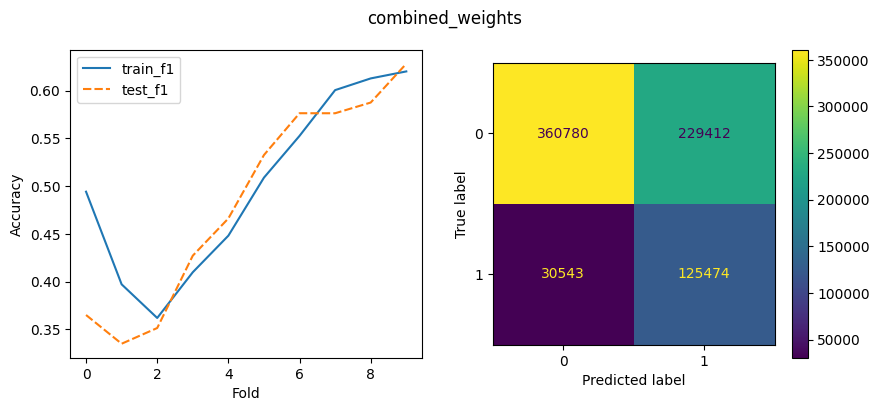

In [39]:
model = LGBMClassifier(random_state=42, verbose=-1)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

scores, cm = evaluate_model(pipeline, n_splits=10, max_train_size=365*24, weights_func=combined_weights)

plot_results(scores, cm, "combined_weights")

In [40]:
mask = X.time >= '2025'
X_from_2025 = X.loc[mask]
y_from_2025 = y.loc[mask]

X_from_2025.shape, y_from_2025.shape

((243170, 113), (243170,))


------------- Overall -------------
Train F1 : 0.669 ± 0.050 | Test  F1 : 0.623 ± 0.034

Completed in: 21.34s.


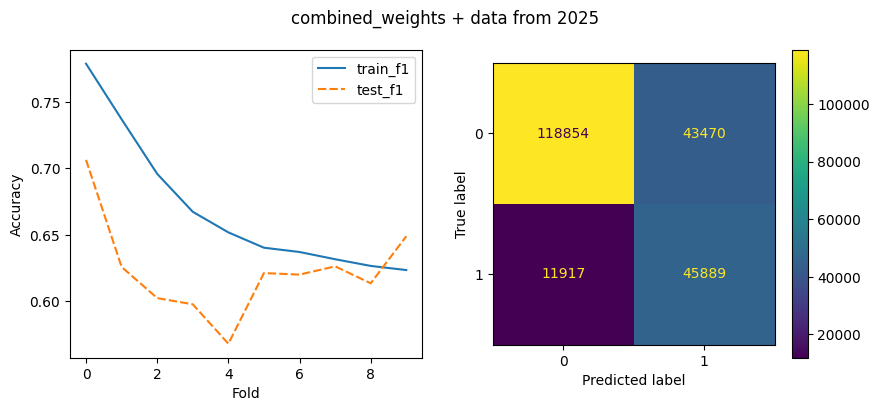

In [41]:
model = LGBMClassifier(random_state=42, verbose=-1)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

scores, cm = evaluate_model(pipeline, X_from_2025, y_from_2025, n_splits=10, weights_func=combined_weights)

plot_results(scores, cm, "combined_weights + data from 2025")


------------- Overall -------------
Train F1 : 0.720 ± 0.060 | Test  F1 : 0.649 ± 0.032

Completed in: 30.22s.


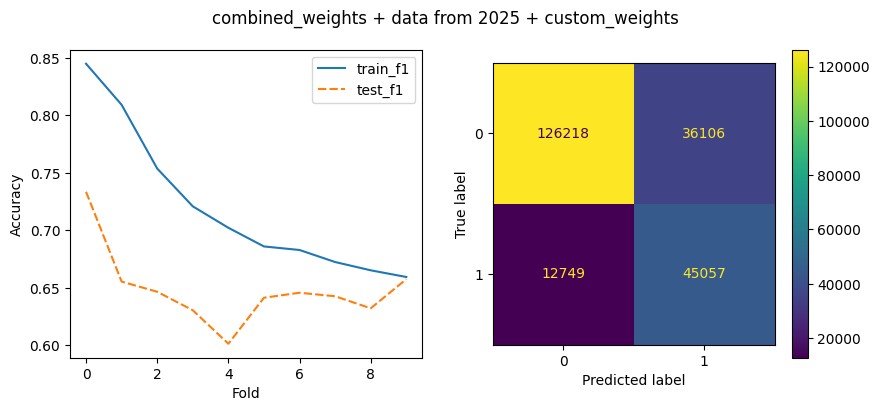

In [42]:
model = LGBMClassifier(
    n_estimators=300,
    max_depth=5,  
    min_child_samples=50,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

scores, cm = evaluate_model(pipeline, X_from_2025, y_from_2025, n_splits=10, weights_func=combined_weights)

plot_results(scores, cm, "combined_weights + data from 2025 + custom_weights")

In [86]:
from app.db.database import Database



with Database("app/db/database.db") as db:
    new_data = db.get_merged(start_date='2026-04-08')

def check_on_new_data(pipeline, new_data=new_data):
    X_new = new_data.copy()
    y_new = X_new.pop(target)
    
    y_preds = pipeline.predict(X_new)
    score = f1_score(y_new, y_preds)
    ConfusionMatrixDisplay(confusion_matrix(y_new, y_preds)).plot()
    plt.title(score)
    plt.show()
    
    res = X_new[['region_id', 'time']]
    res['alarm'] = y_new
    res['prediction'] = y_preds
    res['pred_prob_1'] = pipeline.predict_proba(X_new)[:, 1]
    
    return res

Commiting


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Георгій\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Георгій\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Георгій\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Георгій\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Commiting


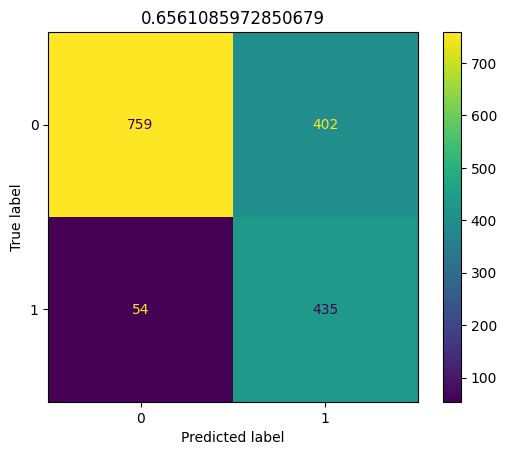

,region_id,time,alarm,prediction,pred_prob_1
0,3,2026-04-09 00:00:00+03:00,0,0,0.096110
1,3,2026-04-09 01:00:00+03:00,0,0,0.145624
2,3,2026-04-09 02:00:00+03:00,0,0,0.237289
3,3,2026-04-09 03:00:00+03:00,0,0,0.189817
4,3,2026-04-09 04:00:00+03:00,0,0,0.149463
...,...,...,...,...,...
1645,31,2026-04-11 13:00:00+03:00,0,0,0.199737
1646,31,2026-04-11 14:00:00+03:00,0,0,0.079664
1647,31,2026-04-11 15:00:00+03:00,0,0,0.094171
1648,31,2026-04-11 16:00:00+03:00,0,0,0.252705


In [18]:
res = check_on_new_data(pipeline, new_data)

In [19]:
with pd.option_context("display.max_rows", None):
    display(res)

,region_id,time,alarm,prediction,pred_prob_1
0,3,2026-04-09 00:00:00+03:00,0,0,0.096110
1,3,2026-04-09 01:00:00+03:00,0,0,0.145624
2,3,2026-04-09 02:00:00+03:00,0,0,0.237289
3,3,2026-04-09 03:00:00+03:00,0,0,0.189817
4,3,2026-04-09 04:00:00+03:00,0,0,0.149463
5,3,2026-04-09 05:00:00+03:00,0,0,0.182354
6,3,2026-04-09 06:00:00+03:00,0,1,0.532030
7,3,2026-04-09 07:00:00+03:00,0,0,0.274953
8,3,2026-04-09 08:00:00+03:00,0,0,0.180122
9,3,2026-04-09 09:00:00+03:00,0,0,0.123065


In [20]:
importance = pd.DataFrame({
    'feature': X.drop(columns='time').columns,
    'importance': pipeline.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

importance.head(20)

,feature,importance
0,region_id,475
108,neighbor_alarm_count,347
84,alarm_status_1h_ago,297
109,hour,211
60,alarms_count_1h_ago,204
32,msg_count_last_3h,194
19,nlp_відбій,189
33,msg_count_last_24h,188
20,nlp_відбій_тривоги,186
27,nlp_повітряна,172


# Maximizing f1 score

## optuna

In [12]:
def objective(trial, X, y, pipeline_factory, n_splits=5, gap=24, max_train_size=None, weights_func=None):
    """
    pipeline_factory(params) -> sklearn Pipeline with a 'model' step.
    Must be a callable so each trial gets a fresh pipeline.
    """
    params = {
        "n_estimators":       trial.suggest_int("n_estimators", 100, 600),
        "max_depth":          trial.suggest_int("max_depth", 3, 8),
        "num_leaves":         trial.suggest_int("num_leaves", 15, 63),
        "min_child_samples":  trial.suggest_int("min_child_samples", 30, 200),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "subsample":          trial.suggest_float("subsample", 0.5, 1.0),
        "subsample_freq":     1,
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":          trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "min_split_gain":     trial.suggest_float("min_split_gain", 0.0, 1.0),
        "random_state":       42,
        "verbose":            -1,
    }

    pipeline = pipeline_factory(params)

    unique_hours = X["time"].sort_values().unique()
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap, max_train_size=max_train_size)
    test_scores = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_hours)):
        train_hours = unique_hours[train_idx]
        test_hours  = unique_hours[test_idx]

        train_mask = X["time"].isin(train_hours)
        test_mask  = X["time"].isin(test_hours)

        X_train, y_train = X[train_mask], y[train_mask]
        X_test,  y_test  = X[test_mask],  y[test_mask]

        sample_weights = weights_func(X_train, y_train) if weights_func else None
        pipeline.fit(X_train, y_train, model__sample_weight=sample_weights)

        score = f1_score(y_test, pipeline.predict(X_test))
        test_scores.append(score)

        # Prune bad trials after each fold
        trial.report(np.mean(test_scores), fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(test_scores)

In [13]:
def pipeline_factory(params):
    """Mirrors your existing pipeline — replace preprocessor with yours."""
    return Pipeline([
        ("preprocessor", preprocessor),          # your existing preprocessor step
        ("model", LGBMClassifier(**params)),
    ])


study_f1 = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),   # prune after fold 5
)

study_f1.optimize(
    lambda trial: objective(
        trial, X_from_2025, y_from_2025,
        pipeline_factory=pipeline_factory,
        n_splits=10,
        gap=24,
        max_train_size=None,
        weights_func=combined_weights,
    ),
    n_trials=100,
    # timeout=3600,
    show_progress_bar=True,
)

print("Best test F1 :", study_f1.best_value)
print("Best params  :", study_f1.best_params)

[I 2026-04-12 09:34:53,816] A new study created in memory with name: no-name-e96b812c-8e17-4b35-8ce8-817b49707aa1


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-12 09:35:30,173] Trial 0 finished with value: 0.6089295573482572 and parameters: {'n_estimators': 287, 'max_depth': 8, 'num_leaves': 50, 'min_child_samples': 132, 'learning_rate': 0.015257808482051183, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 1.599409170128044, 'reg_lambda': 0.16730402817820234, 'min_split_gain': 0.7080725777960455}. Best is trial 0 with value: 0.6089295573482572.
[I 2026-04-12 09:35:48,364] Trial 1 finished with value: 0.5808153094141095 and parameters: {'n_estimators': 110, 'max_depth': 8, 'num_leaves': 55, 'min_child_samples': 66, 'learning_rate': 0.016362239850894633, 'subsample': 0.5917022549267169, 'colsample_bytree': 0.6521211214797689, 'reg_alpha': 0.08730885649333642, 'reg_lambda': 0.039605150456850806, 'min_split_gain': 0.2912291401980419}. Best is trial 0 with value: 0.6089295573482572.
[I 2026-04-12 09:36:14,712] Trial 2 finished with value: 0.5849107171298003 and parameters: {'n_estimators': 406, 'max

## results

In [93]:
best_params_f1 = study_f1.best_params
best_pipeline_f1 = pipeline_factory(best_params_f1)

In [88]:
scores, cm = evaluate_model(
    best_pipeline_f1,
    X=X_from_2025, y=y_from_2025,
    n_splits=10,
    gap=24,
    weights_func=combined_weights,
)


------------- Overall -------------
Train F1 : 0.890 ± 0.064 | Test  F1 : 0.716 ± 0.029

Completed in: 54.17s.


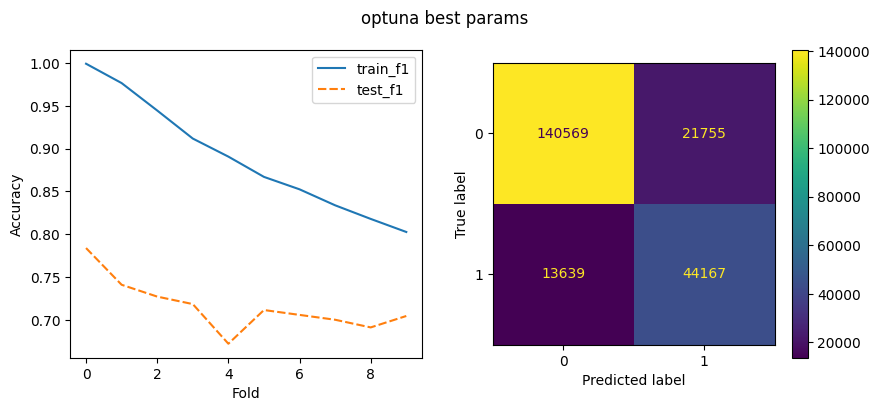

In [89]:
plot_results(scores, cm, "optuna best params")

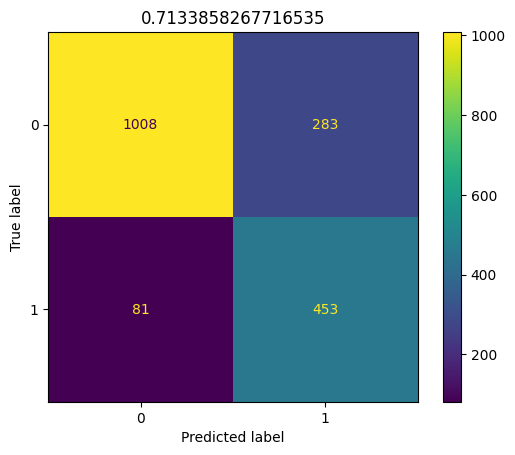

In [94]:
best_pipeline_f1.fit(X_from_2025, y_from_2025, model__sample_weight=combined_weights(X_from_2025, y_from_2025))

res = check_on_new_data(best_pipeline_f1)

In [95]:
with pd.option_context("display.max_rows", None):
    display(res)

,region_id,time,alarm,prediction,pred_prob_1
0,3,2026-04-09 00:00:00+03:00,0,0,0.010075
1,3,2026-04-09 01:00:00+03:00,0,0,0.030250
2,3,2026-04-09 02:00:00+03:00,0,0,0.118127
3,3,2026-04-09 03:00:00+03:00,0,0,0.093674
4,3,2026-04-09 04:00:00+03:00,0,0,0.022414
5,3,2026-04-09 05:00:00+03:00,0,0,0.022791
6,3,2026-04-09 06:00:00+03:00,0,0,0.368868
7,3,2026-04-09 07:00:00+03:00,0,0,0.108021
8,3,2026-04-09 08:00:00+03:00,0,0,0.008031
9,3,2026-04-09 09:00:00+03:00,0,0,0.005641


In [96]:
best_params_f1

{'n_estimators': 587,
 'max_depth': 8,
 'num_leaves': 55,
 'min_child_samples': 72,
 'learning_rate': 0.11747968951351916,
 'subsample': 0.7379505515374946,
 'colsample_bytree': 0.8469291773288569,
 'reg_alpha': 0.32335033304525623,
 'reg_lambda': 1.324254484608713,
 'min_split_gain': 0.08315203489415836}

# Maximizing roc auc score

## optuna

In [19]:
def objective(trial, X, y, pipeline_factory, n_splits=5, gap=24, max_train_size=None, weights_func=None):
    """
    pipeline_factory(params) -> sklearn Pipeline with a 'model' step.
    Must be a callable so each trial gets a fresh pipeline.
    """
    params = {
        "n_estimators":       trial.suggest_int("n_estimators", 100, 600),
        "max_depth":          trial.suggest_int("max_depth", 3, 8),
        "num_leaves":         trial.suggest_int("num_leaves", 15, 63),
        "min_child_samples":  trial.suggest_int("min_child_samples", 30, 200),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "subsample":          trial.suggest_float("subsample", 0.5, 1.0),
        "subsample_freq":     1,
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":          trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "min_split_gain":     trial.suggest_float("min_split_gain", 0.0, 1.0),
        "random_state":       42,
        "verbose":            -1,
    }

    pipeline = pipeline_factory(params)

    unique_hours = X["time"].sort_values().unique()
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap, max_train_size=max_train_size)
    test_scores = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_hours)):
        train_hours = unique_hours[train_idx]
        test_hours  = unique_hours[test_idx]

        train_mask = X["time"].isin(train_hours)
        test_mask  = X["time"].isin(test_hours)

        X_train, y_train = X[train_mask], y[train_mask]
        X_test,  y_test  = X[test_mask],  y[test_mask]

        sample_weights = weights_func(X_train, y_train) if weights_func else None
        pipeline.fit(X_train, y_train, model__sample_weight=sample_weights)

        score = roc_auc_score(y_test, pipeline.predict(X_test))
        test_scores.append(score)

        # Prune bad trials after each fold
        trial.report(np.mean(test_scores), fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(test_scores)

In [20]:
def pipeline_factory(params):
    """Mirrors your existing pipeline — replace preprocessor with yours."""
    return Pipeline([
        ("preprocessor", preprocessor),          # your existing preprocessor step
        ("model", LGBMClassifier(**params)),
    ])


study_roc_auc = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),   # prune after fold 5
)

study_roc_auc.optimize(
    lambda trial: objective(
        trial, X_from_2025, y_from_2025,
        pipeline_factory=pipeline_factory,
        n_splits=10,
        gap=24,
        max_train_size=None,
        weights_func=combined_weights,
    ),
    n_trials=100,
    # timeout=3600,
    show_progress_bar=True,
)

print("Best test F1 :", study_roc_auc.best_value)
print("Best params  :", study_roc_auc.best_params)

[I 2026-04-12 10:41:26,023] A new study created in memory with name: no-name-910621a2-cce3-49b5-b7d9-262a52b05cad


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-12 10:41:59,095] Trial 0 finished with value: 0.7522743814785311 and parameters: {'n_estimators': 287, 'max_depth': 8, 'num_leaves': 50, 'min_child_samples': 132, 'learning_rate': 0.015257808482051183, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 1.599409170128044, 'reg_lambda': 0.16730402817820234, 'min_split_gain': 0.7080725777960455}. Best is trial 0 with value: 0.7522743814785311.
[I 2026-04-12 10:42:17,072] Trial 1 finished with value: 0.7307145194908917 and parameters: {'n_estimators': 110, 'max_depth': 8, 'num_leaves': 55, 'min_child_samples': 66, 'learning_rate': 0.016362239850894633, 'subsample': 0.5917022549267169, 'colsample_bytree': 0.6521211214797689, 'reg_alpha': 0.08730885649333642, 'reg_lambda': 0.039605150456850806, 'min_split_gain': 0.2912291401980419}. Best is trial 0 with value: 0.7522743814785311.
[I 2026-04-12 10:42:43,836] Trial 2 finished with value: 0.732601258268711 and parameters: {'n_estimators': 406, 'max_

## results

In [97]:
best_params_roc_auc = {'n_estimators': 545,
 'max_depth': 7,
 'num_leaves': 55,
 'min_child_samples': 61,
 'learning_rate': 0.14990312773762166,
 'subsample': 0.9993550543596587,
 'colsample_bytree': 0.7001986229502264,
 'reg_alpha': 0.5283198315166077,
 'reg_lambda': 0.03860654671960752,
 'min_split_gain': 0.0967522802778745}
best_pipeline_roc_auc = pipeline_factory(best_params_roc_auc)

In [98]:
scores, cm = evaluate_model(
    best_pipeline_roc_auc,
    X=X_from_2025, y=y_from_2025,
    n_splits=10,
    gap=24,
    weights_func=combined_weights,
)


------------- Overall -------------
Train F1 : 0.901 ± 0.061 | Test  F1 : 0.719 ± 0.025

Completed in: 48.35s.


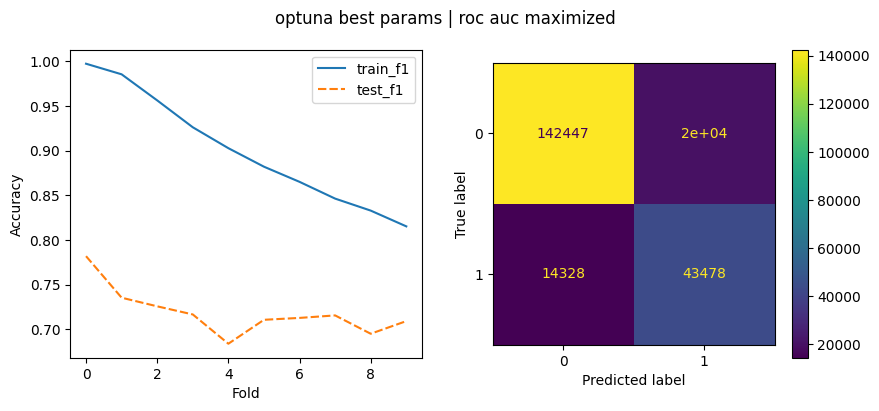

In [99]:
plot_results(scores, cm, "optuna best params | roc auc maximized")

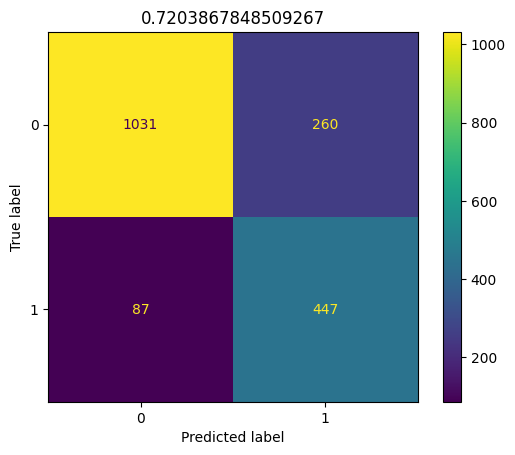

In [104]:
best_pipeline_roc_auc.fit(X_from_2025, y_from_2025, model__sample_weight=combined_weights(X_from_2025, y_from_2025))
res = check_on_new_data(best_pipeline_roc_auc)

In [105]:
with pd.option_context("display.max_rows", None):
    display(res)

,region_id,time,alarm,prediction,pred_prob_1
0,3,2026-04-09 00:00:00+03:00,0,0,0.022203
1,3,2026-04-09 01:00:00+03:00,0,0,0.011335
2,3,2026-04-09 02:00:00+03:00,0,0,0.121496
3,3,2026-04-09 03:00:00+03:00,0,0,0.042702
4,3,2026-04-09 04:00:00+03:00,0,0,0.020537
5,3,2026-04-09 05:00:00+03:00,0,0,0.112617
6,3,2026-04-09 06:00:00+03:00,0,1,0.631743
7,3,2026-04-09 07:00:00+03:00,0,0,0.244399
8,3,2026-04-09 08:00:00+03:00,0,0,0.085395
9,3,2026-04-09 09:00:00+03:00,0,0,0.044180


In [52]:
# best_params_roc_auc = {'n_estimators': 545,
#  'max_depth': 7,
#  'num_leaves': 55,
#  'min_child_samples': 61,
#  'learning_rate': 0.14990312773762166,
#  'subsample': 0.9993550543596587,
#  'colsample_bytree': 0.7001986229502264,
#  'reg_alpha': 0.5283198315166077,
#  'reg_lambda': 0.03860654671960752,
#  'min_split_gain': 0.0967522802778745}

{'n_estimators': 545,
 'max_depth': 7,
 'num_leaves': 55,
 'min_child_samples': 61,
 'learning_rate': 0.14990312773762166,
 'subsample': 0.9993550543596587,
 'colsample_bytree': 0.7001986229502264,
 'reg_alpha': 0.5283198315166077,
 'reg_lambda': 0.03860654671960752,
 'min_split_gain': 0.0967522802778745}

# Best model

Maximizing roc_auc_score gave best performance

In [112]:
best_params = {
    'n_estimators': 545,
    'max_depth': 7,
    'num_leaves': 55,
    'min_child_samples': 61,
    'learning_rate': 0.14990312773762166,
    'subsample': 0.9993550543596587,
    'colsample_bytree': 0.7001986229502264,
    'reg_alpha': 0.5283198315166077,
    'reg_lambda': 0.03860654671960752,
    'min_split_gain': 0.0967522802778745
}

best_pipeline = pipeline_factory(best_params)

best_pipeline.fit(X_from_2025, y_from_2025, model__sample_weight=combined_weights(X_from_2025, y_from_2025))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...), ('drop_cols', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

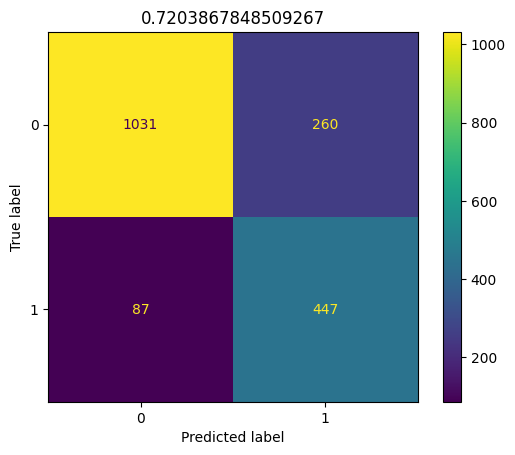

In [114]:
res = check_on_new_data(best_pipeline)

In [115]:
import joblib

models_dir = Path("app/models")
if not models_dir.exists():
    models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(best_pipeline, models_dir / "lgbm_pipeline.joblib")

['app\\models\\lgbm_pipeline.joblib']

In [119]:
import pickle


with open(models_dir / "1__LightGBM_Classifier__v1.pkl", "wb") as f:
    pickle.dump(model, f)

In [117]:
from sklearn.inspection import permutation_importance

base = new_data
X_new_hourly = base.drop(columns=target)
y_new_hourly = base[target]

mask = ~y_new_hourly.isna()
X_new_hourly = X_new_hourly[mask]
y_new_hourly = y_new_hourly[mask]


perm = permutation_importance(
    estimator=best_pipeline,
    X=X_new_hourly,
    y=y_new_hourly,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

top20 = importance_df.head(20).copy()
top20

,feature,importance_mean,importance_std
0,region_id,0.066806,0.006129
109,neighbor_alarm_count,0.008951,0.002101
87,alarm_status_3h_ago,0.007840,0.002459
85,alarm_status_1h_ago,0.007590,0.002057
99,alarm_status_15h_ago,0.006511,0.003320
88,alarm_status_4h_ago,0.004519,0.001424
101,alarm_status_17h_ago,0.004265,0.002271
107,alarm_status_23h_ago,0.003944,0.002457
96,alarm_status_12h_ago,0.003886,0.002014
67,alarms_count_7h_ago,0.003687,0.002731


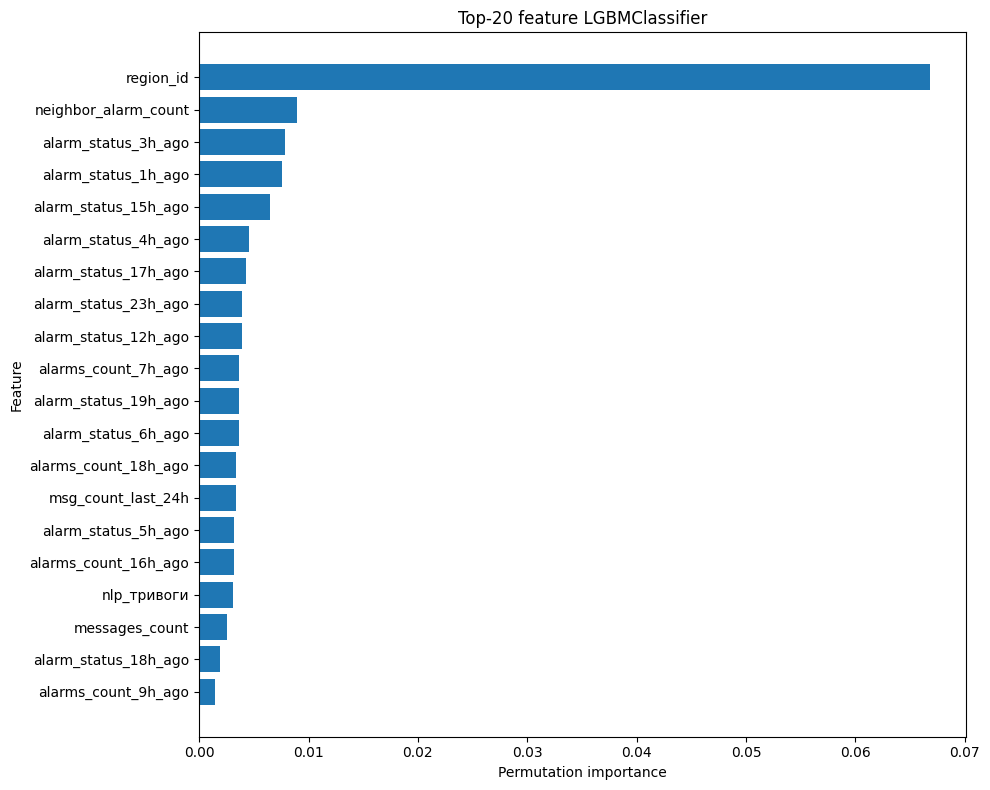

In [118]:
plt.figure(figsize=(10, 8))
plt.barh(top20["feature"][::-1], top20["importance_mean"][::-1])
plt.xlabel("Permutation importance")
plt.ylabel("Feature")
plt.title("Top-20 feature LGBMClassifier")
plt.tight_layout()
plt.show()